In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense,
                                    Dropout, Concatenate, BatchNormalization,
                                    Bidirectional, LSTM, Layer, Multiply, SeparableConv1D)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback
from sklearn.utils.class_weight import compute_class_weight
import pickle
import os
import math
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from nltk import pos_tag
from nltk.corpus import wordnet as wn
import time
from sklearn.metrics import confusion_matrix

# Initialize NLTK resources
nltk.download(['punkt','punkt_tab', 'stopwords', 'wordnet', 'averaged_perceptron_tagger_eng'])

df = pd.read_csv("./LAWHINTAT/glove.6B.300d.txt")
df['sentiment'] = df['sentiment'].map({'positive': 0, 'negative': 1})


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Mounted at /content/drive


In [ ]:
# Data deduplication,Split data
print("\n[Deduplicate]")
initial_count = len(df)
df = df.drop_duplicates(subset='review')
print(f"remove duplicated: {initial_count - len(df)}")

X_raw = df['review']
y = df['sentiment']
x_raw_train_val, x_raw_test, y_train_val, y_test = train_test_split(
      X_raw, y,
      test_size=0.3,
      random_state=42,
      stratify=y
  )
x_raw_train, x_raw_val, y_train, y_val = train_test_split(
    x_raw_train_val,
    y_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_train_val
)

train_df = pd.DataFrame({'raw_text': x_raw_train, 'label': y_train})
val_df = pd.DataFrame({'raw_text': x_raw_val, 'label': y_val})
test_df = pd.DataFrame({'raw_text': x_raw_test, 'label': y_test})

stop_words = set(nltk.corpus.stopwords.words('english')) - {
    'not', 'no', 'never', 'none', 'nor', 'ain', 'aren', 'couldn', 'didn',
    'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'mightn', 'mustn',
    'needn', 'shan', 'shouldn', 'wasn', 'weren', 'won', 'wouldn','it', 'this', 'that', 'is', 'are', 'was', 'were'
}



[Deduplicate]
remove duplicated: 418


In [ ]:
# Abbreviation dictionary, negation processing module
contractions_dict = {
    "ain't": "are not", "aren't": "are not", "can't": "cannot", "could've": "could have", "couldn't": "could not", "didn't": "did not","doesn't": "does not", "don't": "do not", "hadn't": "had not","hasn't": "has not", "haven't": "have not", "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did","how'll": "how will", "how's": "how is", "i'd": "I would","i'll": "I will", "i'm": "I am", "i've": "I have","isn't": "is not", "it'd": "it would", "it'll": "it will","it's": "it is", "let's": "let us", "might've": "might have","must've": "must have", "mustn't": "must not", "needn't": "need not","she'd": "she would", "she'll": "she will", "she's": "she is","should've": "should have", "shouldn't": "should not", "that's": "that is","they'd": "they would", "they'll": "they will", "they're": "they are","they've": "they have", "wasn't": "was not", "we'd": "we would","we'll": "we will", "we're": "we are", "we've": "we have","weren't": "were not", "what'll": "what will", "what're": "what are","what's": "what is", "what've": "what have", "where's": "where is","who'd": "who would", "who'll": "who will", "who's": "who is","why's": "why is", "won't": "will not", "would've": "would have","wouldn't": "would not", "you'd": "you would", "you'll": "you will","you're": "you are", "you've": "you have"
}

contractions_re = re.compile('(%s)' % '|'.join(sorted(contractions_dict.keys(), key=lambda x: (-len(x), x))))
def expand_contractions(text, contractions_dict=contractions_dict):
    def replace(match):
        return contractions_dict[match.group(0)]
    return contractions_re.sub(replace, text)

def enhanced_negation_handling(text):
    text = text.lower() 
    patterns = [
        (r"\b(can)(not)\b", r"\1 \2"),
        (r"\b(don't)\b", "do not"),
        (r"\b(doesn't)\b", "does not"),
        (r"\b(is|was|were)\s+not\b", "not"),
        (r"\bno\s+(\w+)\b", r"not have \1"),
        (r"\black\s+of\b", "not have"),
        (r"\bwon't\b", "will not"),
        (r"\bwouldn't\b", "would not"),
        (r"\b(n't)\b", " not"),
        (r"\bnot\s+have\s+(\w+)\b", r"not_have_\1")
    ]
    for _ in range(2):
        for pat, repl in patterns:
            text = re.sub(pat, repl, text)
    text = re.sub(r"not_have_(\w+)", r"not have \1", text)
    return text

def identify_aspect_terms(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    aspect_terms = []
    current_chunk = []
    for word, pos in tagged:
        if pos.startswith(('NN', 'JJ')): 
            current_chunk.append(word)
        elif current_chunk:
            term = ' '.join(current_chunk)
            if len(term) > 3 and term.lower() not in ['it', 'this', 'that', 'is', 'are', 'was', 'were']:
                aspect_terms.append(term)
            current_chunk = []

    if current_chunk:
        term = ' '.join(current_chunk)
        if len(term) > 3 and term.lower() not in ['it', 'this', 'that']:
            aspect_terms.append(term)

    return list(set(aspect_terms))


In [ ]:
# Data preprocessing ,Replace HTML tags with spaces,enhanced negation handling, 
# recognize aspect words and add special tags, Sort by length in descending order
# Remove punctuation, Standardize spaces, Filter stop words (keep negative words)
def data_processing(text):
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'<[^>]+>', ' ', text) 
    text = enhanced_negation_handling(text)
    text = expand_contractions(text)  
    
    aspect_terms = identify_aspect_terms(text)
    aspect_terms = sorted(aspect_terms, key=len, reverse=True)
    for term in aspect_terms:
        if term in text and f"[ASPECT]{term}[/ASPECT]" not in text:
            text = text.replace(term, f"[ASPECT]{term}[/ASPECT]")

    text = re.sub(r"[^a-zA-Z\s\[\]]", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)

    filtered = [
        w for w in tokens
        if w not in stop_words or w in {'not', 'no', 'never'}
    ]
    return ' '.join(filtered)


In [ ]:
# AdvancedLemmatizer
class AdvancedLemmatizer:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.verb_past_mapping = {
            'broken': 'break',
            'believable': 'believe',
            'appalled': 'appall',
            'made': 'make',
            'went': 'go',
            'had': 'have',
            'did': 'do',
            'said': 'say',
            'taken': 'take',
            'given': 'give',
            'seen': 'see',
            'thought': 'think'
        }
        self.film_terms = {
            'filmmaking', 'screenplay', 'cinematography',
            'nonsensical', 'blockbuster', 'award_winning'
        }

    def get_wordnet_pos(self, treebank_tag):
        if treebank_tag.startswith('J'):
            return wn.ADJ
        elif treebank_tag.startswith('V'):
            return wn.VERB
        elif treebank_tag.startswith('N'):
            return wn.NOUN
        elif treebank_tag.startswith('R'):
            return wn.ADV
        else:
            return None

    def lemmatize(self, text):
        tokens = word_tokenize(text)
        tagged = pos_tag(tokens)
        lemmas = []
        for word, pos in tagged:
            if word.lower() in self.film_terms:
                lemmas.append(word)
                continue
            if word.lower() in self.verb_past_mapping:
                lemmas.append(self.verb_past_mapping[word.lower()])
                continue
            if word.lower() in {'is', 'are', 'was', 'were'}:
                lemmas.append(word)
                continue
            wn_pos = self.get_wordnet_pos(pos) or wn.NOUN
            lemma = self.lemmatizer.lemmatize(word, wn_pos)
            if lemma.endswith('e') and word.endswith('ing'):
                lemma = word
            lemmas.append(lemma)
        return ' '.join(lemmas)

# Initialize the Advanced Lemmatizer
advanced_lemmatizer = AdvancedLemmatizer()


In [ ]:
pip install pandarallel

  Preparing metadata (setup.py) ... done
  Created wheel for pandarallel: filename=pandarallel-1.6.5-py3-none-any.whl size=16674 sha256=51730825457b1c42545cd2c3eb927399f1dafb23489ccbd7acc64563d10c999d
  Stored in directory: /root/.cache/pip/wheels/b9/c6/5a/829298789e94348b81af52ab42c19d49da007306bbcc983827
Successfully built pandarallel


In [ ]:
# Preprocessing acceleration,Processing Data,Preparing data for modeling
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True,nb_workers=8)

def apply_preprocessing(df):
    print("Processing data...")
    start_time = time.time()
    df['processed'] = df['raw_text'].parallel_apply(data_processing)
    df['processed'] = df['processed'].parallel_apply(advanced_lemmatizer.lemmatize)
    result = df[df['processed'].str.len() >= 3]
    print(f"Processing completed in {time.time() - start_time:.2f} seconds")
    return result

train_df = apply_preprocessing(train_df)
val_df = apply_preprocessing(val_df)
test_df = apply_preprocessing(test_df)

X_train = train_df['processed']
y_train_np = train_df['label'].values
X_test = test_df['processed']
y_test_np = test_df['label'].values
X_val = val_df['processed']
y_val_np = val_df['label'].values



INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.
Processing data...


Processing completed in 1883.54 seconds
Processing data...


Processing completed in 461.62 seconds
Processing data...


Processing completed in 967.44 seconds


In [ ]:
# parameter
MAX_NB_WORDS = 25000
MAX_SEQUENCE_LENGTH = 450
FILTER_SIZES = [2, 3, 4, 5, 6]
NUM_FILTERS = 192
BATCH_SIZE = 128
EMBEDDING_DIM = 300

tokenizer = Tokenizer(
    num_words=MAX_NB_WORDS,
    oov_token='<OOV>',
    lower=True
)
tokenizer.fit_on_texts(train_df['processed'])

# Serialize and fill
X_train_seq = tokenizer.texts_to_sequences(train_df['processed'])
X_test_seq = tokenizer.texts_to_sequences(test_df['processed'])
X_val_seq = tokenizer.texts_to_sequences(val_df['processed'])
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH)
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH)

In [ ]:

# load glove
glove_path = "../Model/glove.6B.300d.txt"
def load_glove_embeddings(tokenizer, embedding_dim=300):
    embeddings_index = {}
    with open(glove_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    word_index = tokenizer.word_index
    num_words = min(MAX_NB_WORDS, len(word_index)) + 1
    embedding_matrix = np.zeros((num_words, embedding_dim))
    for word, i in word_index.items():
        if i >= num_words: continue
        if word in embeddings_index:
            embedding_matrix[i] = embeddings_index[word]
        else:
            embedding_matrix[i] = np.random.normal(0, 0.6, embedding_dim)

    aspect_token_index = tokenizer.word_index.get('[aspect]', None)
    if aspect_token_index and aspect_token_index < num_words:
        embedding_matrix[aspect_token_index] = np.random.uniform(-1.0, 1.0, embedding_dim)
        print(f"Aspect token embedding created (index={aspect_token_index})")

    return embedding_matrix, num_words

print("Loading GloVe embeddings...")
embedding_matrix, num_words = load_glove_embeddings(tokenizer)

# calc class weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_np),
    y=y_train_np
)
class_weights_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: Positive={class_weights_dict[0]:.4f}, Negative={class_weights_dict[1]:.4f}")

Loading GloVe embeddings...
Class weights: Positive=0.9962, Negative=1.0038


In [ ]:
# attention layer
class ChannelAttention(Layer):
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channel = input_shape[-1]
        self.shared_dense = Dense(channel // self.ratio,
                                 activation='relu',
                                 kernel_initializer='he_normal',
                                 use_bias=False)
        self.dense1 = Dense(channel, kernel_initializer='he_normal')
        super(ChannelAttention, self).build(input_shape)

    def call(self, x):
        avg_pool = tf.reduce_mean(x, axis=1, keepdims=True)
        max_pool = tf.reduce_max(x, axis=1, keepdims=True)
        # shared fully connected layers
        avg_out = self.shared_dense(avg_pool)
        max_out = self.shared_dense(max_pool)
        # attention Weight
        avg_out = self.dense1(avg_out)
        max_out = self.dense1(max_out)
        # combined
        out = avg_out + max_out
        scale = tf.nn.sigmoid(out)
        return scale

In [ ]:
# Attention layer
class PositionAwareAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1), 
                                 initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        position = tf.range(0, seq_len, dtype=x.dtype)
        position = tf.expand_dims(position, axis=-1) 

        # Calculate dot product of transformed input with position
        pos_att = tf.matmul(x, self.W) 
        # Apply softmax along the sequence dimension
        a = tf.nn.softmax(pos_att, axis=1) 

        return tf.reduce_sum(x * a, axis=1)

In [ ]:
# build model
def build_bilstm_cnn_model(tokenizer, embedding_matrix, num_words):
    input_layer = Input(shape=(MAX_SEQUENCE_LENGTH,))

    aspect_token_index = tokenizer.word_index.get('[ASPECT]', None)
    embedding_layer = Embedding(
        input_dim=num_words,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=True
    )(input_layer)

    if aspect_token_index is not None:
        aspect_embed = tf.keras.layers.Embedding(
            input_dim=1,
            output_dim=EMBEDDING_DIM,
            embeddings_initializer='uniform',
            name='aspect_embed'
        )(tf.zeros_like(input_layer))

        aspect_mask = tf.expand_dims(tf.cast(tf.equal(input_layer, aspect_token_index), -1))
        embedding_layer = tf.keras.layers.Add()([
            embedding_layer * (1 - aspect_mask),
            aspect_embed * aspect_mask
        ])

    embedding_layer = tf.keras.layers.SpatialDropout1D(0.15)(embedding_layer)

    # use separableConv1D to replace some LSTM
    conv_layer = tf.keras.layers.SeparableConv1D(
        256, 3, activation='relu', padding='same')(embedding_layer)

    bilstm = Bidirectional(LSTM(
        384,
        return_sequences=True,
        kernel_regularizer=l2(0.001),
        dropout=0.15,
        recurrent_dropout=0.1,
        activation='tanh'
    ))(conv_layer)

    residual = Conv1D(768, 1, padding='same')(conv_layer)
    bilstm = tf.keras.layers.Add()([bilstm, residual])

    attention_heads = []
    for _ in range(2):
        att = PositionAwareAttention()(bilstm)
        attention_heads.append(att)
    attention = Concatenate()(attention_heads)

    cnn_branches = []
    for sz in FILTER_SIZES:
        conv = Conv1D(128, sz, activation='elu', padding='same',
                      kernel_regularizer=l2(0.003))(bilstm)
        se = ChannelAttention()(conv)
        conv = Multiply()([conv, se])
        max_pool = GlobalMaxPooling1D()(conv)
        cnn_branches.append(max_pool)

    combined = Concatenate()([attention] + cnn_branches)
    combined = BatchNormalization()(combined)
    combined = Dropout(0.5)(combined)

    dense = Dense(512, activation='elu', kernel_regularizer=l2(0.003))(combined)
    dense = BatchNormalization()(dense)
    dense = Dropout(0.45)(dense)

    output = Dense(1, activation='sigmoid', dtype='float32')(dense)

    model = Model(inputs=input_layer, outputs=output)

    lr_schedule = WarmupCosineDecay(
        initial_lr=5e-4,
        warmup_epochs=3,
        decay_steps=2000
    )

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(
            learning_rate=lr_schedule,
            weight_decay=1e-4,
            clipvalue=0.5
        ),
        loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
        jit_compile=True
    )
    return model

In [ ]:
#learning rate scheduler with warmup and cosine decay
class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr=5e-4, warmup_epochs=3, decay_steps=2000):
        super().__init__()
        self.initial_lr = initial_lr
        self.warmup_epochs = warmup_epochs
        self.decay_steps = decay_steps
        self.warmup_steps = warmup_epochs * (len(X_train_pad) // BATCH_SIZE)

    def __call__(self, step):
        warmup_lr = self.initial_lr * tf.cast(step, tf.float32) / tf.cast(self.warmup_steps, tf.float32)

        cosine_decay = 0.5 * (1 + tf.cos(
            tf.constant(math.pi) * tf.cast(step - self.warmup_steps, tf.float32) / tf.cast(self.decay_steps, tf.float32)
        ))
        decay_lr = self.initial_lr * cosine_decay

        return tf.cond(
            step < self.warmup_steps,
            lambda: warmup_lr,
            lambda: decay_lr
        )

    def get_config(self):
        return {
            'initial_lr': self.initial_lr,
            'warmup_epochs': self.warmup_epochs,
            'decay_steps': self.decay_steps
        }

In [ ]:
# SWA Callback
class SWA(tf.keras.callbacks.Callback):
    def __init__(self, swa_epoch):
        super().__init__()
        self.swa_epoch = swa_epoch
        self.swa_weights = None

    def on_epoch_end(self, epoch, logs=None):
        if epoch == self.swa_epoch:
            self.swa_weights = self.model.get_weights()
        elif epoch > self.swa_epoch and self.swa_weights is not None:
            for i in range(len(self.swa_weights)):
                self.swa_weights[i] = (self.swa_weights[i] * (epoch - self.swa_epoch) +
                                       self.model.get_weights()[i]) / (epoch - self.swa_epoch + 1)

    def on_train_end(self, logs=None):
        if self.swa_weights is not None:
            self.model.set_weights(self.swa_weights)
            self.model.save_weights('swa_model.weights.h5')

In [ ]:
# setting up distributed training strategy and  mixed precision strategy, build models within a strategy
strategy = tf.distribute.MirroredStrategy()
print(f'Number of devices: {strategy.num_replicas_in_sync}')
policy = tf.keras.mixed_precision.Policy('mixed_bfloat16')
tf.keras.mixed_precision.set_global_policy(policy)
print('Mixed precision enabled')

with strategy.scope():
    model = build_bilstm_cnn_model(tokenizer, embedding_matrix, num_words)
    model.summary()

def prepare_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=10000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = prepare_dataset(X_train_pad, y_train_np, shuffle=True)
val_dataset = prepare_dataset(X_val_pad, y_val_np)
test_dataset = prepare_dataset(X_test_pad, y_test_np)


Number of devices: 1
Mixed precision enabled


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 450)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 450, 300)  │  7,500,300 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 450, 300)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d    │ (None, 450, 256)  │     77,956 │ spatial_dropout1… │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 450, 768)  │  1,969,152 │ separable_conv1d… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 450, 768)  │    197,376 │ separable_conv1d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 450, 768)  │          0 │ bidirectional[0]… │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 450, 128)  │    196,736 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 450, 128)  │    295,040 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 450, 128)  │    393,344 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 450, 128)  │    491,648 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 450, 128)  │    589,952 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_attention   │ (None, 1, 128)    │      4,224 │ conv1d_1[0][0]    │
│ (ChannelAttention)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_attention_1 │ (None, 1, 128)    │      4,224 │ conv1d_2[0][0]    │
│ (ChannelAttention)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_attention_2 │ (None, 1, 128)    │      4,224 │ conv1d_3[0][0]    │
│ (ChannelAttention)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_attention_3 │ (None, 1, 128)    │      4,224 │ conv1d_4[0][0]    │
│ (ChannelAttention)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ channel_attention_4 │ (None, 1, 128)    │      4,224 │ conv1d_5[0][0]    │
│ (ChannelAttention)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_aware_att… │ (None, 768)       │        768 │ add[0][0]         │
│ (PositionAwareAtte… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_aware_att… │ (None, 768)       │        768 │ add[0][0]       

 Total params: 12,860,049 (49.06 MB)

 Trainable params: 12,854,673 (49.04 MB)

 Non-trainable params: 5,376 (21.00 KB)

In [ ]:
# callback list
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=3,
        min_delta=0.0005,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.weights.h5',
        save_best_only=True,
        save_weights_only=True,
        monitor='val_auc',
        mode='max',
        verbose=1
    ),
    SWA(swa_epoch=5)
]

In [ ]:
# model train
print("Starting training...")
start_time = time.time()
history = model.fit(
    train_dataset,
    epochs=25,
    validation_data=val_dataset,
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)
print(f"Training completed in {time.time() - start_time:.2f} seconds")

Starting training...
Epoch 1/25
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5222 - auc: 0.5324 - loss: 7.0606
Epoch 1: val_auc improved from -inf to 0.85972, saving model to best_model.weights.h5
217/217 ━━━━━━━━━━━━━━━━━━━━ 721s 3s/step - accuracy: 0.5223 - auc: 0.5326 - loss: 7.0593 - val_accuracy: 0.7748 - val_auc: 0.8597 - val_loss: 5.8062
Epoch 2/25
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6708 - auc: 0.7248 - loss: 5.5256
Epoch 2: val_auc improved from 0.85972 to 0.91678, saving model to best_model.weights.h5
217/217 ━━━━━━━━━━━━━━━━━━━━ 704s 3s/step - accuracy: 0.6710 - auc: 0.7250 - loss: 5.5234 - val_accuracy: 0.8168 - val_auc: 0.9168 - val_loss: 3.9602
Epoch 3/25
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7525 - auc: 0.8273 - loss: 3.6133
Epoch 3: val_auc improved from 0.91678 to 0.92325, saving model to best_model.weights.h5
217/217 ━━━━━━━━━━━━━━━━━━━━ 701s 3s/step - accuracy: 0.7525 - auc: 0.8273 - loss: 3.6113 - val_accuracy: 0.7992 - val

In [ ]:
# model ensemble evaluation
def ensemble_predict(models, weights, X, batch_size=1024):
    predictions = []
    for model, weight in zip(models, weights):
        pred = model.predict(X, batch_size=batch_size, verbose=0)
        predictions.append(pred * weight)
    return np.sum(predictions, axis=0) / np.sum(weights)

print("\nRunning ensemble prediction")

base_model = build_bilstm_cnn_model(tokenizer, embedding_matrix, num_words)

# load weights
base_model.load_weights('best_model.weights.h5')
base_model2 = build_bilstm_cnn_model(tokenizer, embedding_matrix, num_words)
base_model2.load_weights('swa_model.weights.h5')



Running ensemble prediction


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 1 variables whereas the saved optimizer has 95 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# ensemble prediction
models = [base_model, base_model2]
weights = [0.7, 0.3]
y_pred_proba = ensemble_predict(models, weights, X_test_pad)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

In [ ]:
# calculation indicators
test_acc = accuracy_score(y_test_np, y_pred)
precision = precision_score(y_test_np, y_pred)
recall = recall_score(y_test_np, y_pred)
f1 = f1_score(y_test_np, y_pred)
auc_score = tf.keras.metrics.AUC()(y_test_np, y_pred_proba).numpy()
test_loss = log_loss(y_test_np, y_pred_proba)



Test Set Performance:
- Accuracy: 0.8978
- AUC: 0.9623
- Precision: 0.9008
- Recall: 0.8933
- F1 Score: 0.8970
- Loss: 0.3019


Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      7465
           1       0.90      0.89      0.90      7410

    accuracy                           0.90     14875
   macro avg       0.90      0.90      0.90     14875
weighted avg       0.90      0.90      0.90     14875



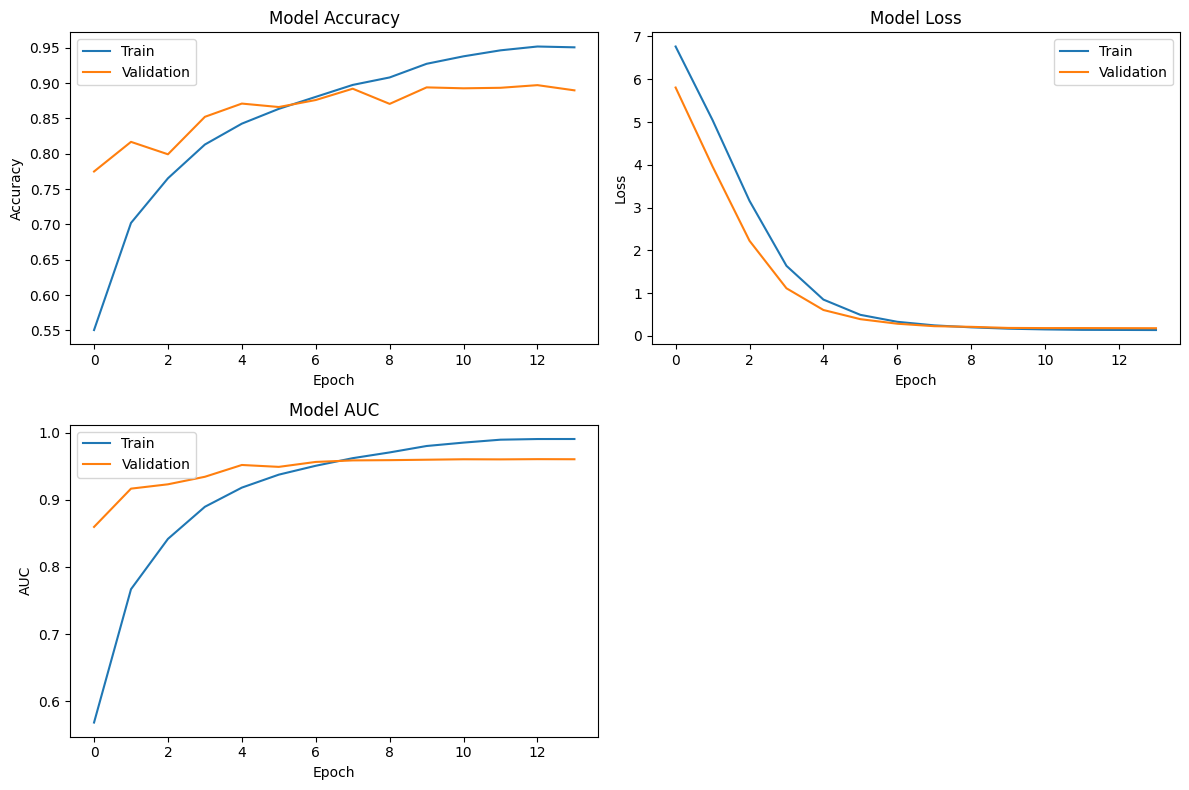

In [ ]:
print(f"""
Test Set Performance:
- Accuracy: {test_acc:.4f}
- AUC: {auc_score:.4f}
- Precision: {precision:.4f}
- Recall: {recall:.4f}
- F1 Score: {f1:.4f}
- Loss: {test_loss:.4f}

""")
print("Classification Report:")
print(classification_report(y_test_np, y_pred))

# plot training history
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(history.history['auc'], label='Train')
plt.plot(history.history['val_auc'], label='Validation')
plt.title('Model AUC')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()


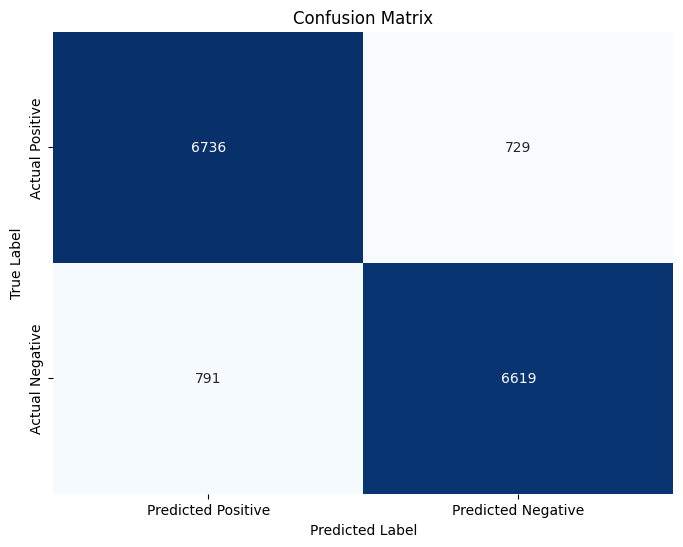

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test_np, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Positive', 'Predicted Negative'],
            yticklabels=['Actual Positive', 'Actual Negative'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()